# The Great American Coffee Taste Test: How Demographics, Preferences, and Expertise Influence Coffee Spending

**Members**:

Ban Xiaomeng A0333405N

Ye Chulin A0298881E

Shi Boyuan A0333653E

Yi Haotian A0333374E

Chen Ke Yuan Kowin A0329512H

**Group:** Lucky Coffee

## Introduction

For this project, we use `coffee_survey.csv`, a dataset released by TidyTuesday on 14 May 2024. The dataset comes from The Great American Coffee Taste Test, an online tasting event organised by James Hoffmann and Cometeer in October 2023 (Hoffmann, 2023). In this event, around 4,000 people in the United States brewed four blind-labelled coffees at home while following a YouTube livestream, and then filled in a survey about their demographics, brewing habits, favourite drinks, self-rated coffee expertise, and monthly coffee spending (Hoffman, 2023; McKeon Aloe, 2023). The final dataset contains 4,042 responses and 57 variables. An early summary of the survey noted that respondents were more likely to be younger, male, and interested in lighter roasts, compared with the broader population of coffee drinkers (Hoffman, 2023). The dataset was also later used by Maven Analytics (2024) as an open visualisation challenge. In this report, we are mainly interested in coffee spending. More specifically, we want to see which demographic factors, coffee preferences, and self-rated expertise are linked to higher coffee spending in this sample. We break this into three smaller questions:

1. **Demographics.** How does age relate to monthly coffee spending?
2. **Favourite drink.** How does favorite coffee drink affect monthly coffee spending patterns?
3. **Self-rated expertise.** Does higher expertise mean more spending on coffee equipment, monthly coffee spending, or both?


We then use three figures to examine the data from different angles: a proportion stacked histogram for demographic patterns, a heatmap for coffee drink preferences, and a line chart for expertise and equipment spending (Claude, 2026). However, this dataset is based on a convenience sample, since participants chose to join a coffee-themed YouTube event (McKeon Aloe, 2023). This means the sample likely contains more coffee enthusiasts than the general public. Because of this, the results in this report should be read as patterns within this sample rather than causal conclusions or estimates for all coffee drinkers in the United States (Claude, 2026; TidyTuesday, 2024). 

## Data Cleaning

The coffee dataset file was loaded from Github, a copy of the data was made, then duplicate values were dropped if applicable.  To answer the three questions, these variables were carefully chosen: total_spend, age, favorite, expertise, and spent_equipment. These were chosen after further exploration of the data using a simple Pandas value_counts function: the sampling of this dataset is biased towards young adults, full-time employees, Caucasians, and people who have Bachelor degrees. Since the dataset had many missing values, a summary of missing values was made for each variable, to check if there is sufficient data to carry on with further analysis (Claude, 2026).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
#load raw csv file from Github
url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/refs/heads/main/data/2024/2024-05-14/coffee_survey.csv"
coffee_survey = pd.read_csv(url)

#make a copy
coffee_analysis = coffee_survey.copy()

#drop duplicates (if any)

coffee_analysis = coffee_analysis.drop_duplicates()

#number of observations and variables
coffee_analysis.shape

(4042, 57)

In [3]:
#print head (many columns have missing data)

coffee_analysis.head()

,submission_id,age,cups,where_drink,brew,brew_other,purchase,purchase_other,favorite,favorite_specify,...,spent_equipment,value_equipment,gender,gender_specify,education_level,ethnicity_race,ethnicity_race_specify,employment_status,number_children,political_affiliation
0,gMR29l,18-24 years old,NaN,NaN,NaN,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BkPN0e,25-34 years old,NaN,NaN,Pod/capsule machine (e.g. Keurig/Nespresso),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,W5G8jj,25-34 years old,NaN,NaN,Bean-to-cup machine,NaN,NaN,NaN,Regular drip coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4xWgGr,35-44 years old,NaN,NaN,Coffee brewing machine (e.g. Mr. Coffee),NaN,NaN,NaN,Iced coffee,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,QD27Q8,25-34 years old,NaN,NaN,Pour over,NaN,NaN,NaN,Latte,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:


#variables to use for graphs: age, total_spend, favorite, expertise, and spent_equipment. It 
#will be subsetted for analysis. 

coffee_analysis = coffee_analysis[['age','total_spend','favorite','expertise','spent_equipment']]

#check for missing data and create missing data summaries

missing_data = (1 - (coffee_analysis.count()/ 4042)) * 100

print(missing_data)



age                 0.766947
total_spend        13.137061
favorite            1.533894
expertise           2.572984
spent_equipment    13.260762
dtype: float64


In [5]:

# subset the dataset for the three figures
fig_1 = coffee_analysis[['age','total_spend']].copy()

#rename column names for seaborn legend
fig1colnames = ['age', 'Total Spent']
fig_1.columns = fig1colnames

fig_2 = coffee_analysis[['favorite', 'total_spend']].copy()

fig_3 = coffee_analysis[['expertise','spent_equipment','total_spend']].copy()
fig3colnames = ['expertise','spent_equipment','Total Spent']
fig_3.columns = fig3colnames

In [6]:
#drop missing values
fig_1 = fig_1.dropna()
fig_2 = fig_2.dropna()
fig_3 = fig_3.dropna()


fig_1.shape
fig_2.shape
fig_3.shape

(3461, 3)

## Figure 1- Proportion Stacked Histogram

A proportion stacked histogram is used to show the relative distribution of spending categories within each age group. Respondents aged under 18 were removed due to the very small sample size of fewer than 15 responses (McKeon Aloe, 2023). The six original spending brackets were collapsed into three groups for clearer comparison. Age groups are sorted in ascending order for easier interpretation.

In [7]:
#check for values
fig_1['age'].value_counts()

age
25-34 years old    1794
35-44 years old     850
18-24 years old     384
45-54 years old     254
55-64 years old     148
>65 years old        68
<18 years old        13
Name: count, dtype: int64

In [8]:

#drop age <18

fig_1 = fig_1[fig_1['age'] != '<18 years old']

#Sort values by age, so it is easier to interpret in the plot

fig_1 = fig_1.sort_values(by='age',ascending=True)

fig_1['age'].unique()





array(['18-24 years old', '25-34 years old', '35-44 years old',
       '45-54 years old', '55-64 years old', '>65 years old'],
      dtype=object)

In [9]:
#collapse total_spend categories into three categories 

cond = [

    fig_1['Total Spent'] == '>$100',
    fig_1['Total Spent'] == '$80-$100',
    fig_1['Total Spent'] == '$60-$80',
    fig_1['Total Spent'] == '$40-$60',
    fig_1['Total Spent'] == '$20-$40',
    fig_1['Total Spent'] == '<$20',
]

choice = ['>$80','>$80', '$40-$80','$40-$80','<$40','<$40']

fig_1['Total Spent'] = np.select(cond,choice,default='unknown')



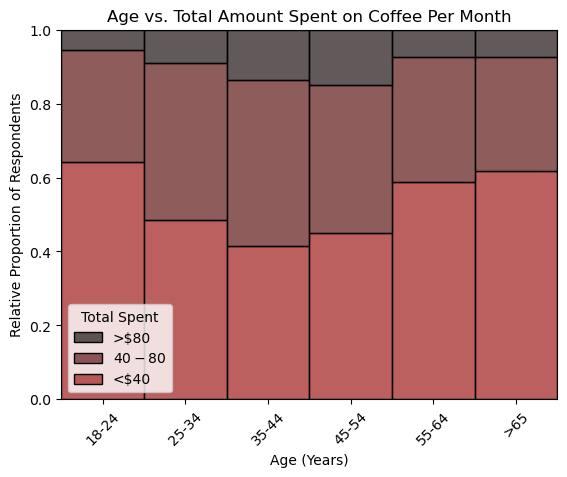

In [10]:
# make a relative proportion histogram chart

sns.histplot(fig_1, x = 'age', palette='dark:brown', hue = 'Total Spent',
             hue_order=['>$80','$40-$80','<$40'], multiple='fill')

plt.xticks(rotation=45, ticks= fig_1['age'].unique(), labels= ['18-24', '25-34', '35-44',
       '45-54', '55-64', '>65'])
plt.title('Age vs. Total Amount Spent on Coffee Per Month')
plt.xlabel('Age (Years)')
plt.ylabel('Relative Proportion of Respondents')
plt.show()





## Figure 2- Bivariate Histogram (Heatmap)

As many of the variables in this dataset are categorical, using a scatterplot would not be appropriate as it would lead to overplotting. For this second figure, a bivariate histogram was chosen, to show the relationship between favorite coffee drink vs. total amount spent on coffee per month as a heatmap visualisation. Similar to the workflow of the first figure, the number of respondents per coffee drink and total amount of coffee spent per month was analysed to ensure that sample sizes per group in each variable are sufficient for plotting.

In [11]:
fig_2['favorite'].value_counts()

favorite
Pourover                            967
Latte                               606
Regular drip coffee                 375
Cappuccino                          301
Espresso                            290
Cortado                             274
Americano                           221
Iced coffee                         136
Mocha                               103
Other                               102
Cold brew                            93
Blended drink (e.g. Frappuccino)     43
Name: count, dtype: int64

In [12]:
fig_2['total_spend'].value_counts()



total_spend
$20-$40     1293
$40-$60     1050
<$20         427
$60-$80      387
$80-$100     223
>$100        131
Name: count, dtype: int64

In [13]:
#sort the total_spend values by ascending order

cond = [
    fig_2['total_spend'] == '>$100',
    fig_2['total_spend'] == '$80-$100',
    fig_2['total_spend'] == '$60-$80',
    fig_2['total_spend'] == '$40-$60',
    fig_2['total_spend'] == '$20-$40',
    fig_2['total_spend'] == '<$20',
]

choice = ['1','2','3','4','5','6']

fig_2['total_spend'] = np.select(cond,choice,default='unknown')


fig_2 = fig_2.sort_values(by='total_spend',ascending=True)


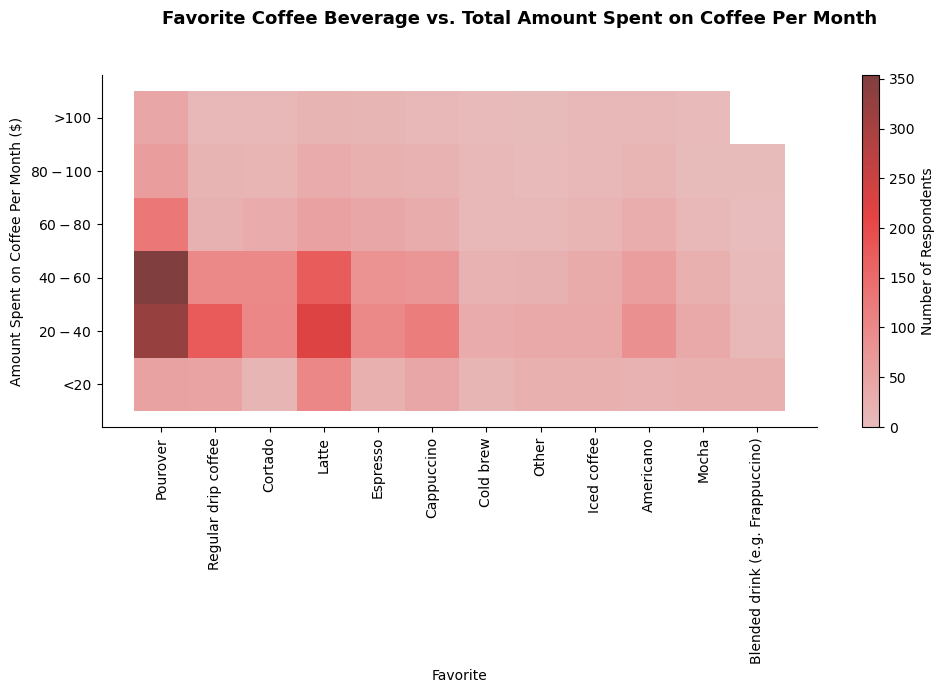

In [ ]:
#plot the heatmap

g2 = sns.displot(fig_2, kind = 'hist', x = 'favorite', y = 'total_spend',
            height = 4, aspect = 1.618, color='brown',cbar=True, cbar_kws = {'label' : 'Number of Respondents'})

g2.set_axis_labels('Favorite', 'Amount Spent on Coffee Per Month ($)')
g2.figure.set_size_inches(10, 5)
g2.figure.suptitle('Favorite Coffee Beverage vs. Total Amount Spent on Coffee Per Month',
                  fontsize = 13, fontweight = 'bold')
g2.figure.subplots_adjust(top = 0.85)
plt.xticks(rotation=90)
plt.yticks(ticks=fig_2['total_spend'].unique(), labels= ['>100','$80-$100','$60-$80','$40-$60','$20-$40','<20'])

plt.show()

## Figure 3- Line Plot

For the last figure, a line plot was used. This is to illustrate the relationship between self-rated coffee expertise vs. amount spent on coffee equipment, with a slight nuance- there is an additional hue variable of total amount of coffee spent per month to subset this relationship. The total_spend variable was collapsed into three categories just like in Figure 1. The spent_equipment variable, which is a categorical variable showing a range of prices, is converted into a numerical variable by taking its midpoint, so that the plot is able to take the average amount spent on coffee equipment for each expertise rating. Once again, the variables are analysed to ensure there are sufficient sample sizes per group. The equipment spending and expertise variables are sorted by ascending order, for easier interpretability. 

In [15]:
fig_3['spent_equipment'].value_counts()

spent_equipment
More than $1,000    772
$100-$300           741
$500-$1000          629
$300-$500           589
$50-$100            309
Less than $20       235
$20-$50             186
Name: count, dtype: int64

In [16]:
fig_3['expertise'].value_counts()

expertise
7.0     827
6.0     759
5.0     508
8.0     452
4.0     296
3.0     233
2.0     141
1.0     133
9.0      80
10.0     32
Name: count, dtype: int64

In [17]:
#collapse total_spend categories into three categories 

cond = [

    fig_3['Total Spent'] == '>$100',
    fig_3['Total Spent'] == '$80-$100',
    fig_3['Total Spent'] == '$60-$80',
    fig_3['Total Spent'] == '$40-$60',
    fig_3['Total Spent'] == '$20-$40',
    fig_3['Total Spent'] == '<$20',
]

choice = ['>$80','>$80', '$40-$80','$40-$80','<$40','<$40']

fig_3['Total Spent'] = np.select(cond,choice,default='unknown')



In [18]:
fig_3['spent_equipment'].unique()

array(['$500-$1000', '$50-$100', '$100-$300', '$300-$500',
       'More than $1,000', '$20-$50', 'Less than $20'], dtype=object)

In [19]:
#convert spent_equipment categories into numerical categories and sort them by ascending order

cond = [

    fig_3['spent_equipment'] == 'Less than $20',
    fig_3['spent_equipment'] == '$20-$50',
    fig_3['spent_equipment'] == '$50-$100',
    fig_3['spent_equipment'] == '$100-$300',
    fig_3['spent_equipment'] == '$300-$500',
    fig_3['spent_equipment'] == '$500-$1000',
    fig_3['spent_equipment'] == 'More than $1,000'
]

choice = ['10','35','75','200','400','750','1000']

fig_3['spent_equipment'] = np.select(cond,choice,default='unknown')

fig_3['spent_equipment'] = fig_3['spent_equipment'].astype('int')

fig_3 = fig_3.sort_values(by=['spent_equipment','expertise'], ascending=True)

fig_3['spent_equipment'].unique()
fig_3['expertise'].unique()

array([ 1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

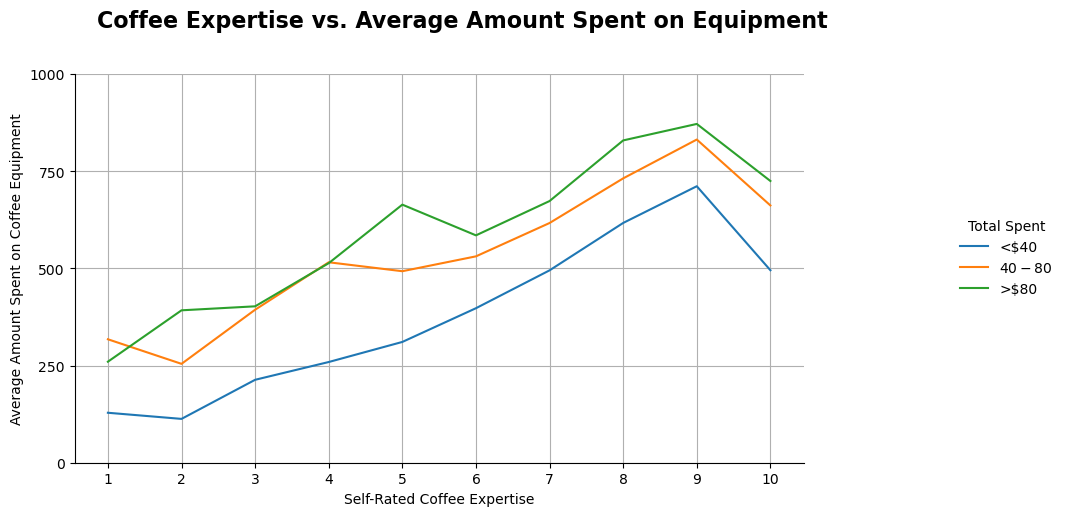

In [20]:
#plot the line chart

g3 = sns.relplot(kind='line',data = fig_3, x = 'expertise' , y = 'spent_equipment', 
               hue = 'Total Spent', hue_order=['<$40', '$40-$80','>$80'],
               height = 8, aspect = 0.5, errorbar=None)
g3.set_axis_labels('Self-Rated Coffee Expertise', 'Average Amount Spent on Coffee Equipment')
g3.figure.set_size_inches(12, 5)
g3.figure.suptitle('Coffee Expertise vs. Average Amount Spent on Equipment',
                  fontsize = 16, fontweight = 'bold')
g3.figure.subplots_adjust(top = 0.85)

plt.xticks(ticks= fig_3['expertise'].unique(), labels= [1,2,3,4,5,6,7,8,9,10])
plt.grid()
plt.yticks(ticks= [0,250,500,750,1000], labels= [0,250,500,750,1000])
plt.show()

# Discussion

Figure 1- This figure shows that people spend more on coffee per month during the working ages between 25 and 54. This makes sense in a post-COVID, western societal context- it can be assumed that people pay for more coffee for a caffeine boost during a working day. Another assumption is that people may pay for more coffee at outside establishments (requiring extra service fees), rather than their homes in a working day due to its convenience.


Figure 2- The results show that pourover and lattes are the most commonly reported favorite drinks. People typically spend $20-$60 a month on coffee, and this is prevalent in most drinks, especially pourovers, regular drip coffee and lattes. People typically would not too much money over their favorite coffee drink. This suggests that people would pay for good quality coffee, without breaking the bank. 


Figure 3- This plot shows that self-rated coffee expertise is positively associated with the amount spent on coffee equipment. Each line represents how much was spent on coffee per month. The lines represent the average amount the respondents spent on coffee equipment (y-value) on each expertise rating (x-value). However, people who rated themselves highly and spent more on coffee equipment do not necessarily spend more on coffee per month. An example of this is the blue line of people who spent less than $40 per month on coffee, at ranking number 9. In most cases, buying coffee drinks from outside establishments as mentioned earlier, tend to be more expensive than making it in home. This seems to apply for those who have a strong expertise on coffee.

# Conclusion

In conclusion, it is shown that age, favourite coffee drink, and the relationship between self-rated coffee expertise vs. amount of equipment spent has an effect on how much a respondent spends on coffee per month. In particular for those who spend more on coffee, it is typically those who are young adults, those who rated themselves highly in terms of coffee expertise, and those who spent more on coffee equipment. Based on personal observations, people pay for more coffee due to the following factors: convenience of outside establishments and a caffeine boost during the working day. There are some interesting insights that can be acknowledged from this study. First, respondents would pay for their favourite drink, typically of high quality like pourovers and lattes, but are sensible with their spending. Lastly, a strong investment in coffee equipment does not mean people spend more on coffee per month- perhaps it's more worth it to make coffee at home.

# AI Declaration

Claude Code in GitHub was used to write the introduction, formulate the research questions, data cleaning and which variables and plot types to use for the figures. We have made manual revisions to their outputs to ensure that it makes sense and fact checked against it with the references. The coding was done manually. We are responsible for the quality of the submitted work. 

# Work Allocation


Introduction and Data Cleaning- Yi Haotian

Fig. 1- Ye Chulin

Fig. 2- Chen Ke Yuan Kowin 

Fig. 3- Shi Boyuan

Discussion and Conclusion- Ban Xiaomeng

Everybody has reviewed the report.

# References

1. Hoffmann, J. (2023, October 21). Surprising and fascinating results from the taste test [Video]. YouTube. https://www.youtube.com/watch?v=bMOOQfeloH0

2. TidyTuesday. (2024, May 14). The Great American Coffee Taste Test [Data set]. R for Data Science Online Learning Community. https://github.com/rfordatascience/tidytuesday/tree/main/data/2024/2024-05-14

3. McKeon Aloe, R. (2023, November). Great American Coffee Taste Test breakdown. Medium. https://rmckeon.medium.com/great-american-coffee-taste-test-breakdown-7f3fdcc3c41d

4. Maven Analytics. (2024). Maven coffee challenge. https://mavenanalytics.io/challenges/maven-coffee-challenge
